<a href="https://colab.research.google.com/github/DamirDenis-Tudor/CAVA2026Lab/blob/main/w4_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HOMEWORK**

* **2.5bp**

  a) Extend the Hough transform demo and plot all the possible lines, by their Hough response, above a given threshold (relative to the maximum value).

  b) Increase the size of the Hough space response for the given demo (*Intel8086* photo). What happens to the most probable line?
  
* **1.5bp** Using the channel-wise image histogram, write a procedure for a better initialization of K-Means.

* **3.5bp** Implement disparity estimation based on minimizing the sum of squared differences between 9x9 image patches in the stereo vision framework. The searching space in the right image is a fixed size image patch of a size given as input (e.g. a 27x27 image patch). The disparity is the horizontal displacement between the position of the center pixel in the left image and the position in the right image that minimizes the SSD.

* **3.5bp** Using the description of the method [here](https://www.sciencedirect.com/science/article/pii/S1077314296900405?via%3Dihub), implement the disparity map estimation method. What type of algorithm is this? How can it be improved?
As a reference, you can download stereo vision images from [here](https://home.cvlab.cs.tsukuba.ac.jp/dataset).



### Solution 1

In [26]:
import math
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def compute_hough_space_extended(img, rho_bin=200, theta_bin=300, threshold_ratio=0.5):
  h, w = img.shape

  theta_max = 1.0 * math.pi
  theta_min = 0.0

  rho_max = math.hypot(h, w)
  rho_min = 0.0

  hough_space = np.zeros((rho_bin, theta_bin), dtype=np.int32)

  for y_coord in range(h):
    for x_coord in range(w):
      if img[y_coord, x_coord] != 0:
        for itheta in range(theta_bin):
          theta = theta_min + (1.0 * itheta) * (theta_max / theta_bin)
          rho = x_coord * math.cos(theta) + y_coord * math.sin(theta)

          if rho >= rho_min and rho < rho_max:
            irho = int(rho_bin * (rho - rho_min) / (rho_max - rho_min))
            if 0 <= irho < rho_bin:
              hough_space[irho, itheta] += 1

  hough_space_normalized = np.ceil(255 * (hough_space - hough_space.min()) / (hough_space.max() - hough_space.min())) if hough_space.max() > hough_space.min() else np.zeros_like(hough_space)

  max_hough_response = hough_space.max()
  threshold_value = max_hough_response * threshold_ratio

  rhos_indices, thetas_indices = np.where(hough_space >= threshold_value)

  detected_lines_params = []
  for i in range(len(rhos_indices)):
    r_idx = rhos_indices[i]
    t_idx = thetas_indices[i]

    r = rho_min + (r_idx / rho_bin) * (rho_max - rho_min)
    t = theta_min + (t_idx / theta_bin) * (theta_max - theta_min)
    detected_lines_params.append((r, t))

  return hough_space_normalized.astype(np.uint8), detected_lines_params

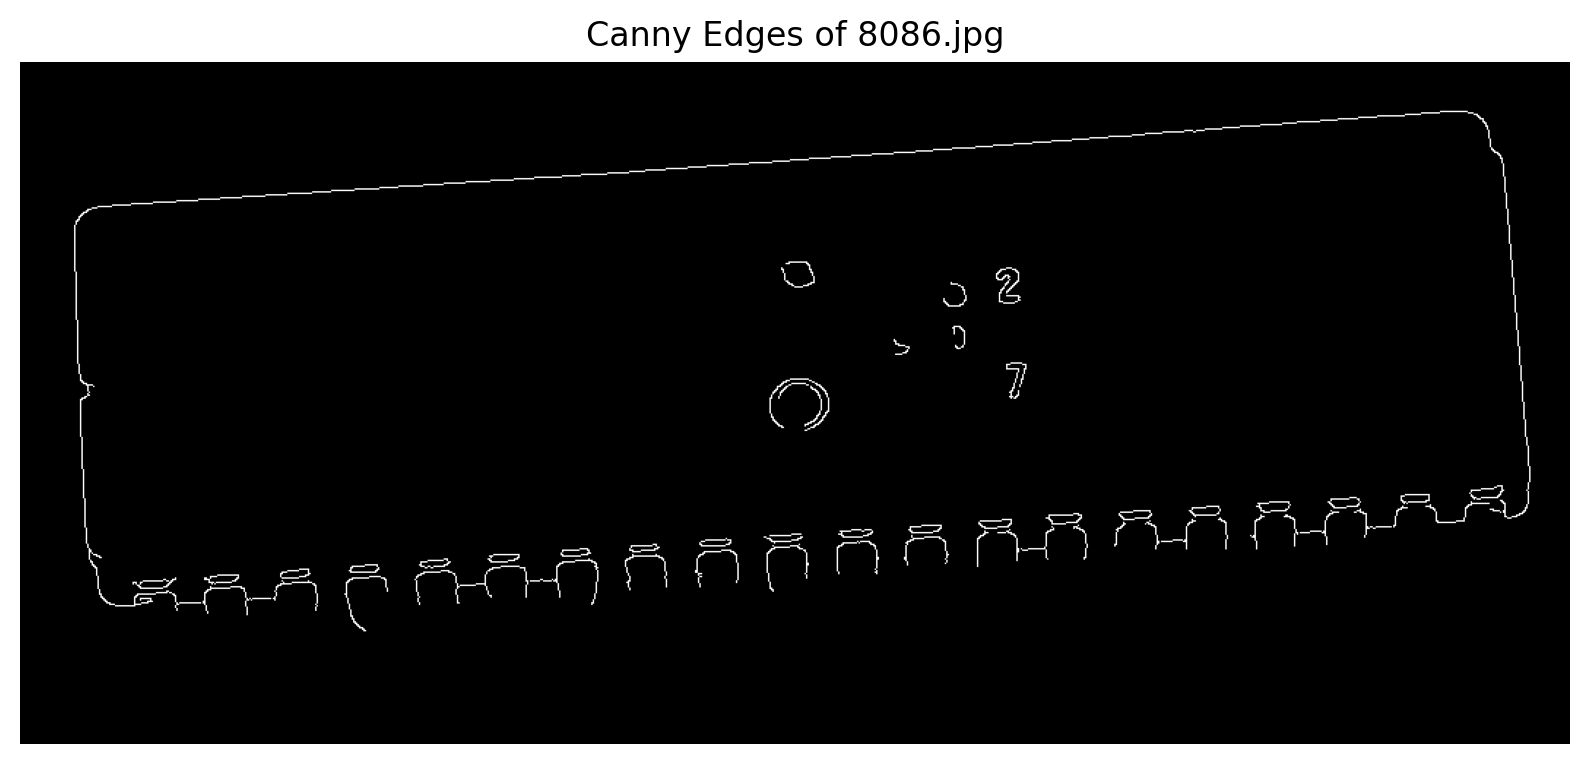

In [22]:
image_rgb = cv.imread("/content/drive/MyDrive/Master I/Computer Vision/lab4/8086.jpg")
image_rgb = cv.GaussianBlur(image_rgb,(5, 5), 0)
img_gray = cv.cvtColor(image_rgb, cv.COLOR_BGR2GRAY)

edges = cv.Canny(img_gray, 100, 200)

plt.figure(figsize=(10, 5))
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges of 8086.jpg')
plt.axis('off')
plt.show()

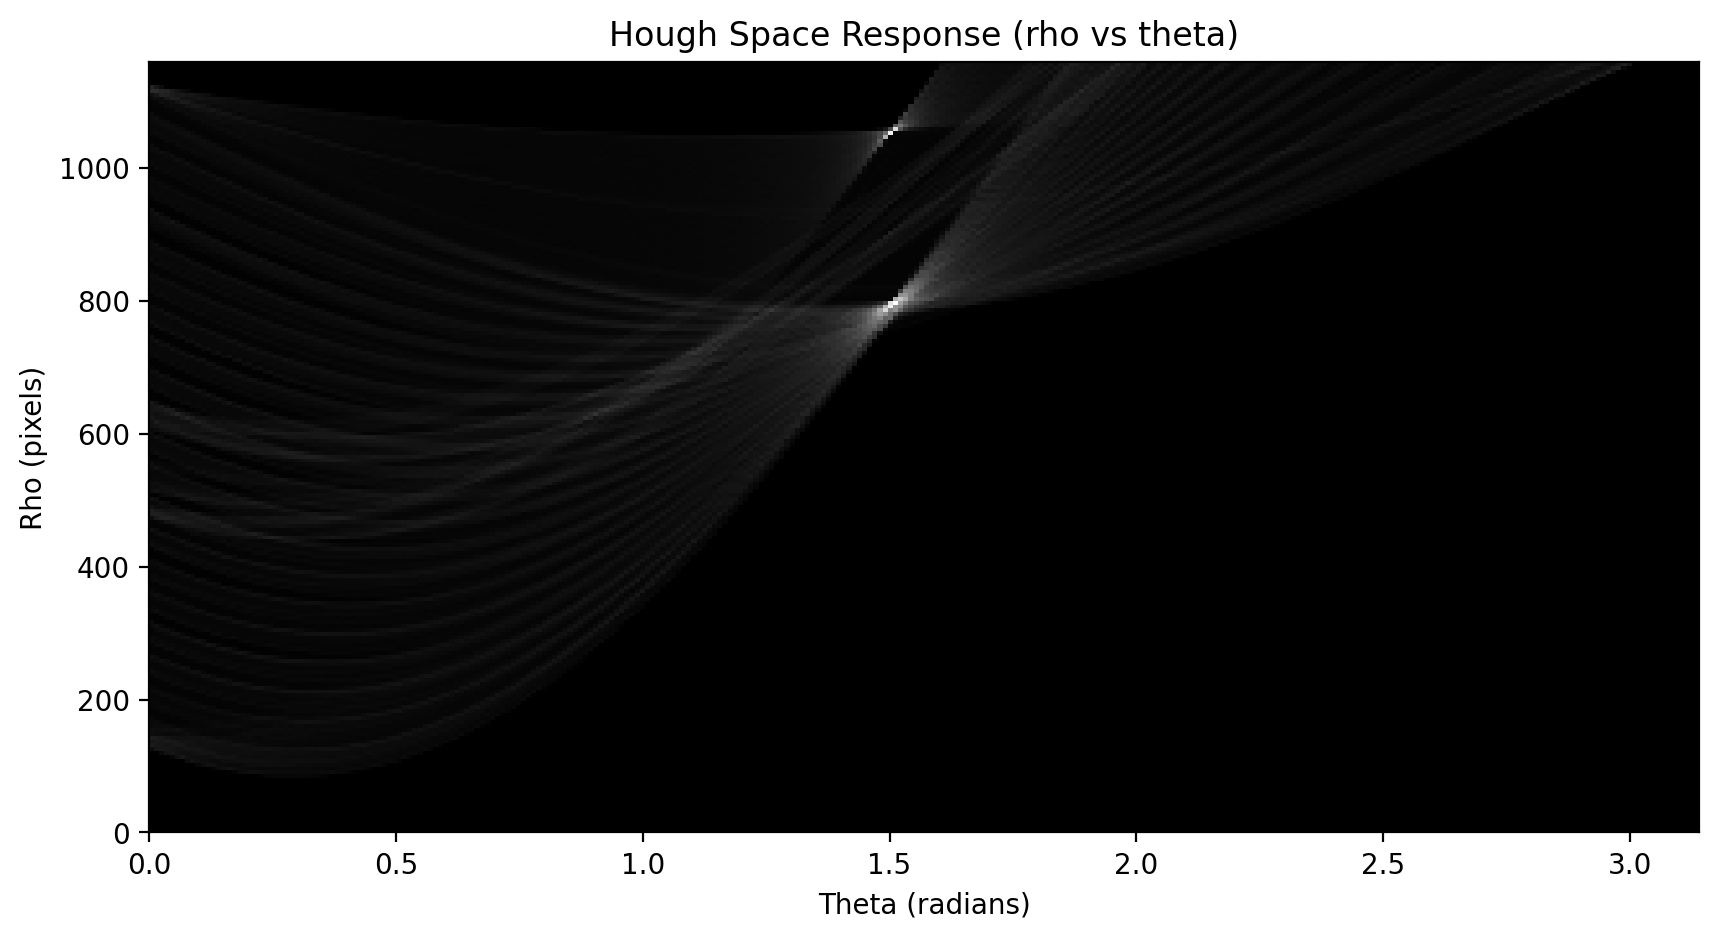

In [23]:
threshold_ratio = 0.5

hough_response, lines_params = compute_hough_space_extended(edges, threshold_ratio=threshold_ratio)

plt.figure(figsize=(10, 5))
plt.imshow(hough_response, cmap='gray', extent=[0, math.pi, 0, math.hypot(edges.shape[0], edges.shape[1])])
plt.title('Hough Space Response (rho vs theta)')
plt.xlabel('Theta (radians)')
plt.ylabel('Rho (pixels)')
plt.gca().set_aspect('auto')
plt.show()

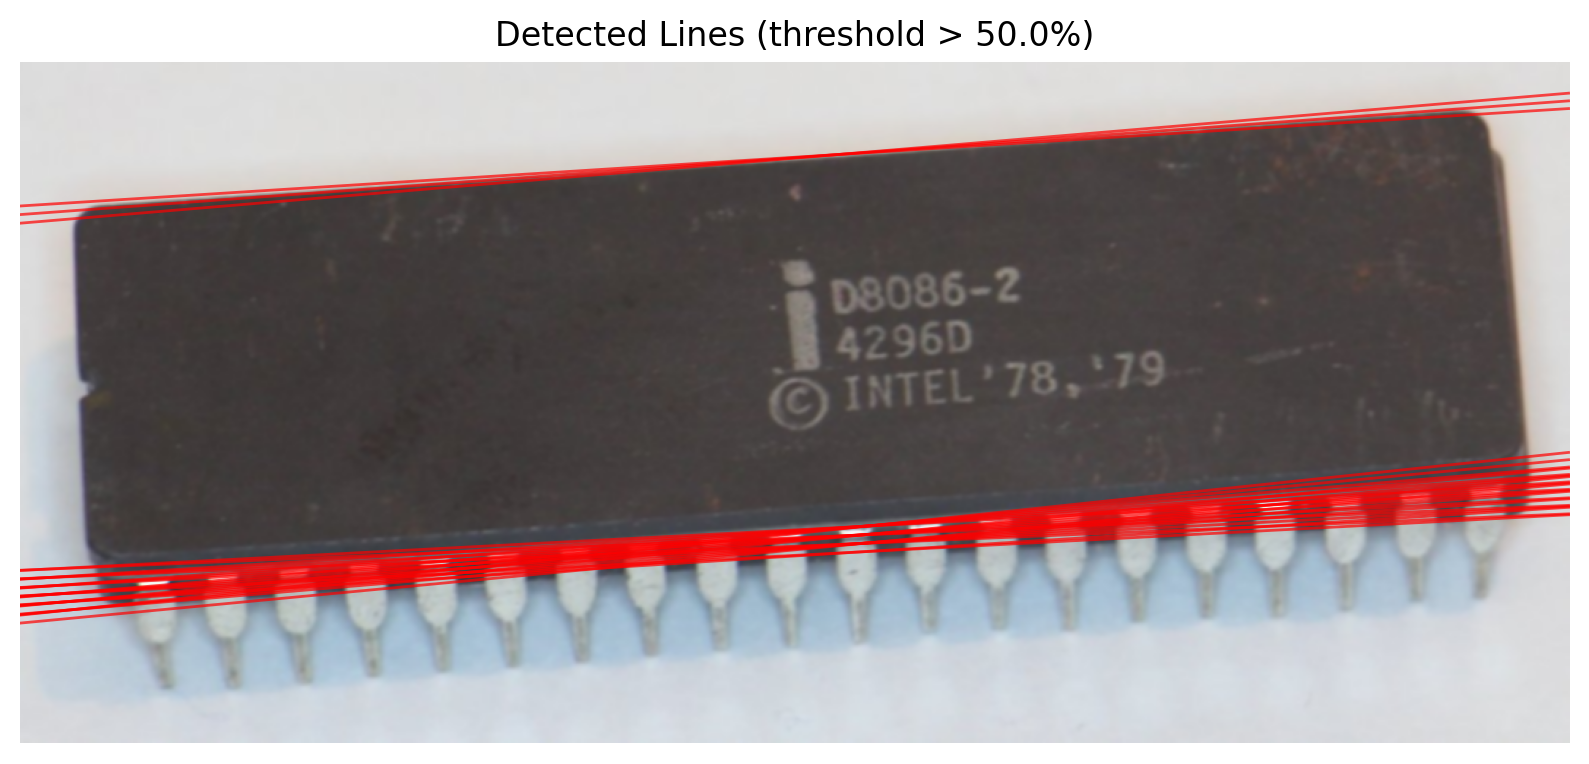

In [24]:
plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(image_rgb, cv.COLOR_BGR2RGB))
plt.title(f'Detected Lines (threshold > {threshold_ratio*100}%)')

h, w = edges.shape
for r, t in lines_params:
    if abs(math.sin(t)) > 1e-6:
        x_coords = np.arange(w)
        y_coords = (r - x_coords * math.cos(t)) / math.sin(t)
        valid_indices = (y_coords >= 0) & (y_coords < h)
        plt.plot(x_coords[valid_indices], y_coords[valid_indices], color='red', linestyle='-', linewidth=1, alpha=0.7)
    elif abs(math.cos(t)) > 1e-6:
        y_coords = np.arange(h)
        x_coords = (r - y_coords * math.sin(t)) / math.cos(t)
        valid_indices = (x_coords >= 0) & (x_coords < w)
        plt.plot(x_coords[valid_indices], y_coords[valid_indices], color='red', linestyle='-', linewidth=1, alpha=0.7)

plt.xlim(0, w)
plt.ylim(h, 0)
plt.axis('off')
plt.show()

### Solution for 2

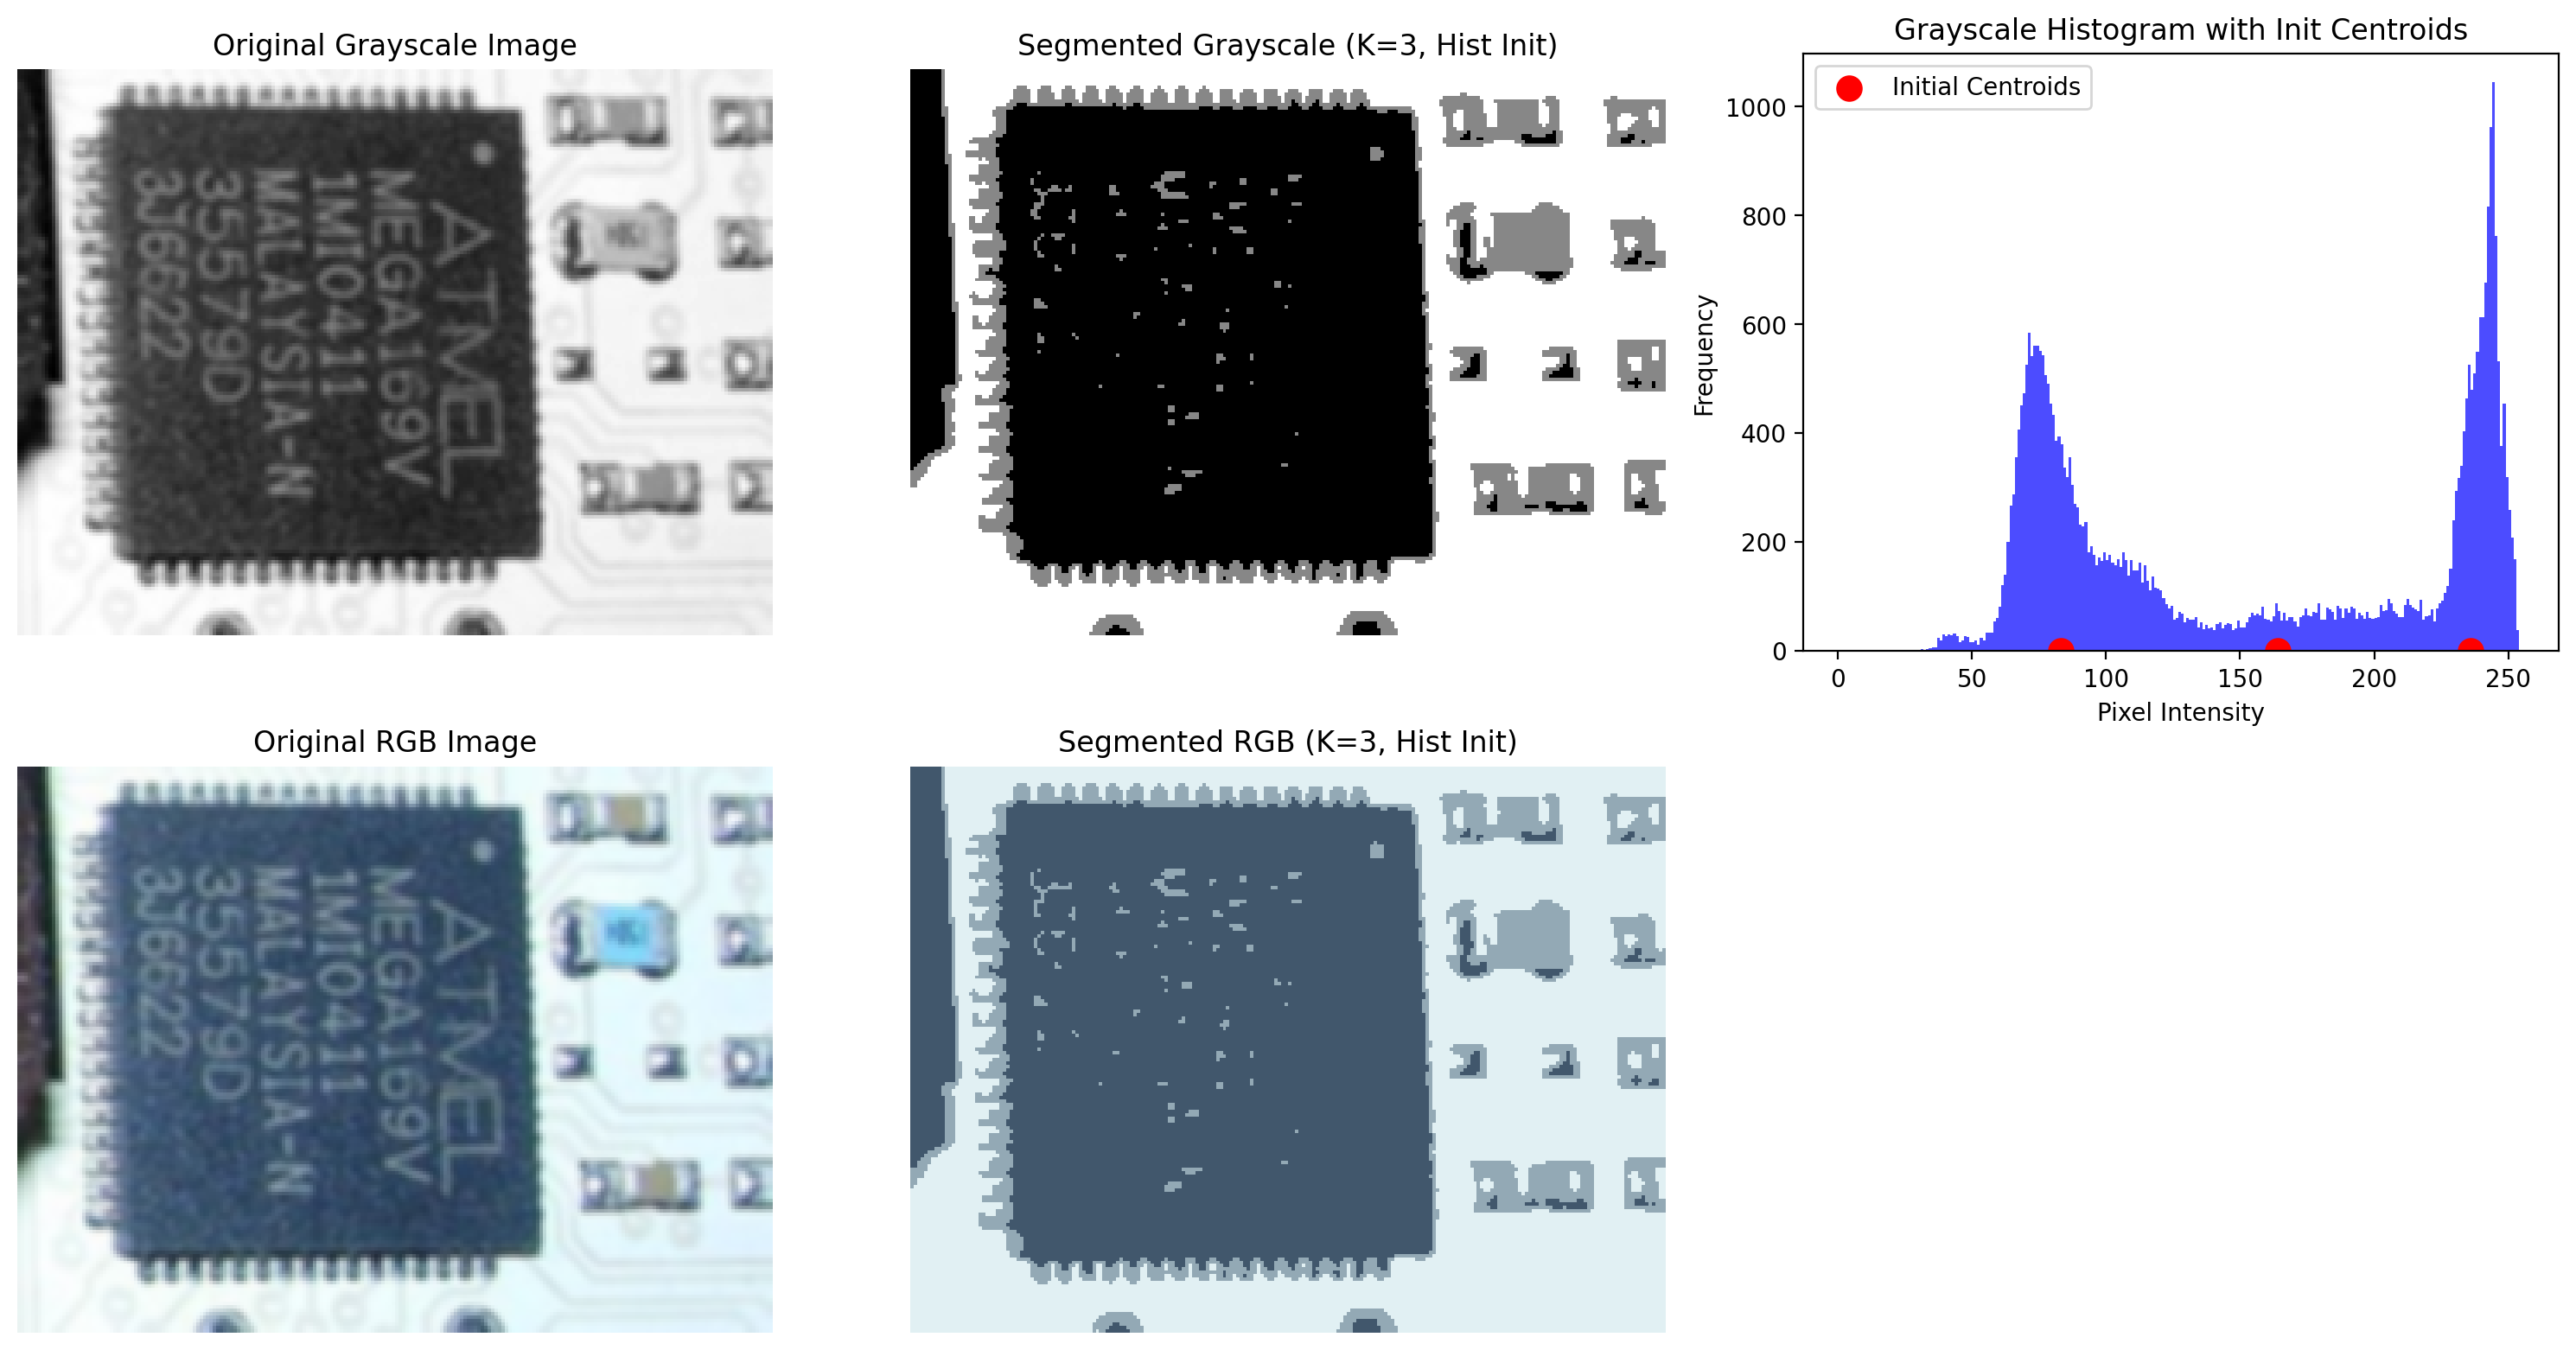

In [25]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def get_initial_centroids_from_histogram(image_channels, k):
    all_pixels = image_channels.flatten()
    hist, bins = np.histogram(all_pixels, bins=256, range=[0, 256])

    if k == 0:
        return np.array([])

    peak_indices = np.argsort(hist)[-k:]
    initial_centroids = bins[peak_indices] + (bins[1]-bins[0])/2
    return np.sort(initial_centroids)


def kmeans_from_histogram_init(image, k):
    pixel_values = image.reshape((-1, image.shape[-1] if len(image.shape) == 3 else 1)).astype(np.float32)

    if len(image.shape) == 3:
        avg_intensity = np.mean(image, axis=2).flatten() if image.shape[-1] == 3 else image.flatten()
        initial_centroids_1D = get_initial_centroids_from_histogram(avg_intensity, k)

        if image.shape[-1] == 3:
            criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.85)
            initial_centroids = np.array([np.full(image.shape[-1], c) for c in initial_centroids_1D], dtype=np.float32)
        else:
            initial_centroids = initial_centroids_1D.reshape(-1, 1)
    else:
        initial_centroids = get_initial_centroids_from_histogram(image, k).reshape(-1, 1)

    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.85)

    _, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_PP_CENTERS, centers=initial_centroids)

    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(image.shape)

    return segmented_image, centers, labels

image_path = "/content/drive/MyDrive/Master I/Computer Vision/lab4/fingerprint.jpg"
original_image_rgb = cv.imread(image_path)
original_image_rgb = cv.GaussianBlur(original_image_rgb,(5, 5), 0)
original_image_gray = cv.cvtColor(original_image_rgb, cv.COLOR_BGR2GRAY)

k_clusters = 3

segmented_gray_hist_init, centers_gray_hist_init, labels_gray_hist_init = kmeans_from_histogram_init(original_image_gray, k_clusters)

segmented_rgb_hist_init, centers_rgb_hist_init, labels_rgb_hist_init = kmeans_from_histogram_init(original_image_rgb, k_clusters)


plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_image_gray, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(segmented_gray_hist_init, cmap='gray')
plt.title(f'Segmented Grayscale (K={k_clusters}, Hist Init)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.hist(original_image_gray.flatten(), bins=256, range=[0, 256], color='blue', alpha=0.7)
plt.scatter(centers_gray_hist_init, np.zeros_like(centers_gray_hist_init), marker='o', color='red', s=100, label='Initial Centroids')
plt.title('Grayscale Histogram with Init Centroids')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(2, 3, 4)
plt.imshow(cv.cvtColor(original_image_rgb, cv.COLOR_BGR2RGB))
plt.title('Original RGB Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv.cvtColor(segmented_rgb_hist_init, cv.COLOR_BGR2RGB))
plt.title(f'Segmented RGB (K={k_clusters}, Hist Init)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Solution for 3

In [27]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

def calculate_ssd(patch1, patch2):
    return np.sum((patch1 - patch2)**2)

def compute_disparity_map_ssd(left_img, right_img, patch_size=9, search_range=27):
    h, w = left_img.shape
    disparity_map = np.zeros((h, w), dtype=np.uint8)
    half_patch = patch_size // 2

    search_range = max(patch_size, search_range)
    half_search = search_range // 2

    for y in range(half_patch, h - half_patch):
        for x in range(half_patch, w - half_patch):
            left_patch = left_img[y - half_patch : y + half_patch + 1,
                                  x - half_patch : x + half_patch + 1]

            best_ssd = np.inf
            best_disparity = 0

            search_start_x = max(half_patch, x - half_search)
            search_end_x = min(w - half_patch, x + half_search)

            for x_right in range(search_start_x, search_end_x):
                if (x_right - half_patch >= 0) and (x_right + half_patch < w):
                    right_patch = right_img[y - half_patch : y + half_patch + 1,
                                            x_right - half_patch : x_right + half_patch + 1]

                    ssd = calculate_ssd(left_patch, right_patch)

                    if ssd < best_ssd:
                        best_ssd = ssd
                        best_disparity = abs(x - x_right)

            disparity_map[y, x] = best_disparity * (255 // search_range)

    return disparity_map

Computing disparity map with patch size: 9x9 and search range: 100


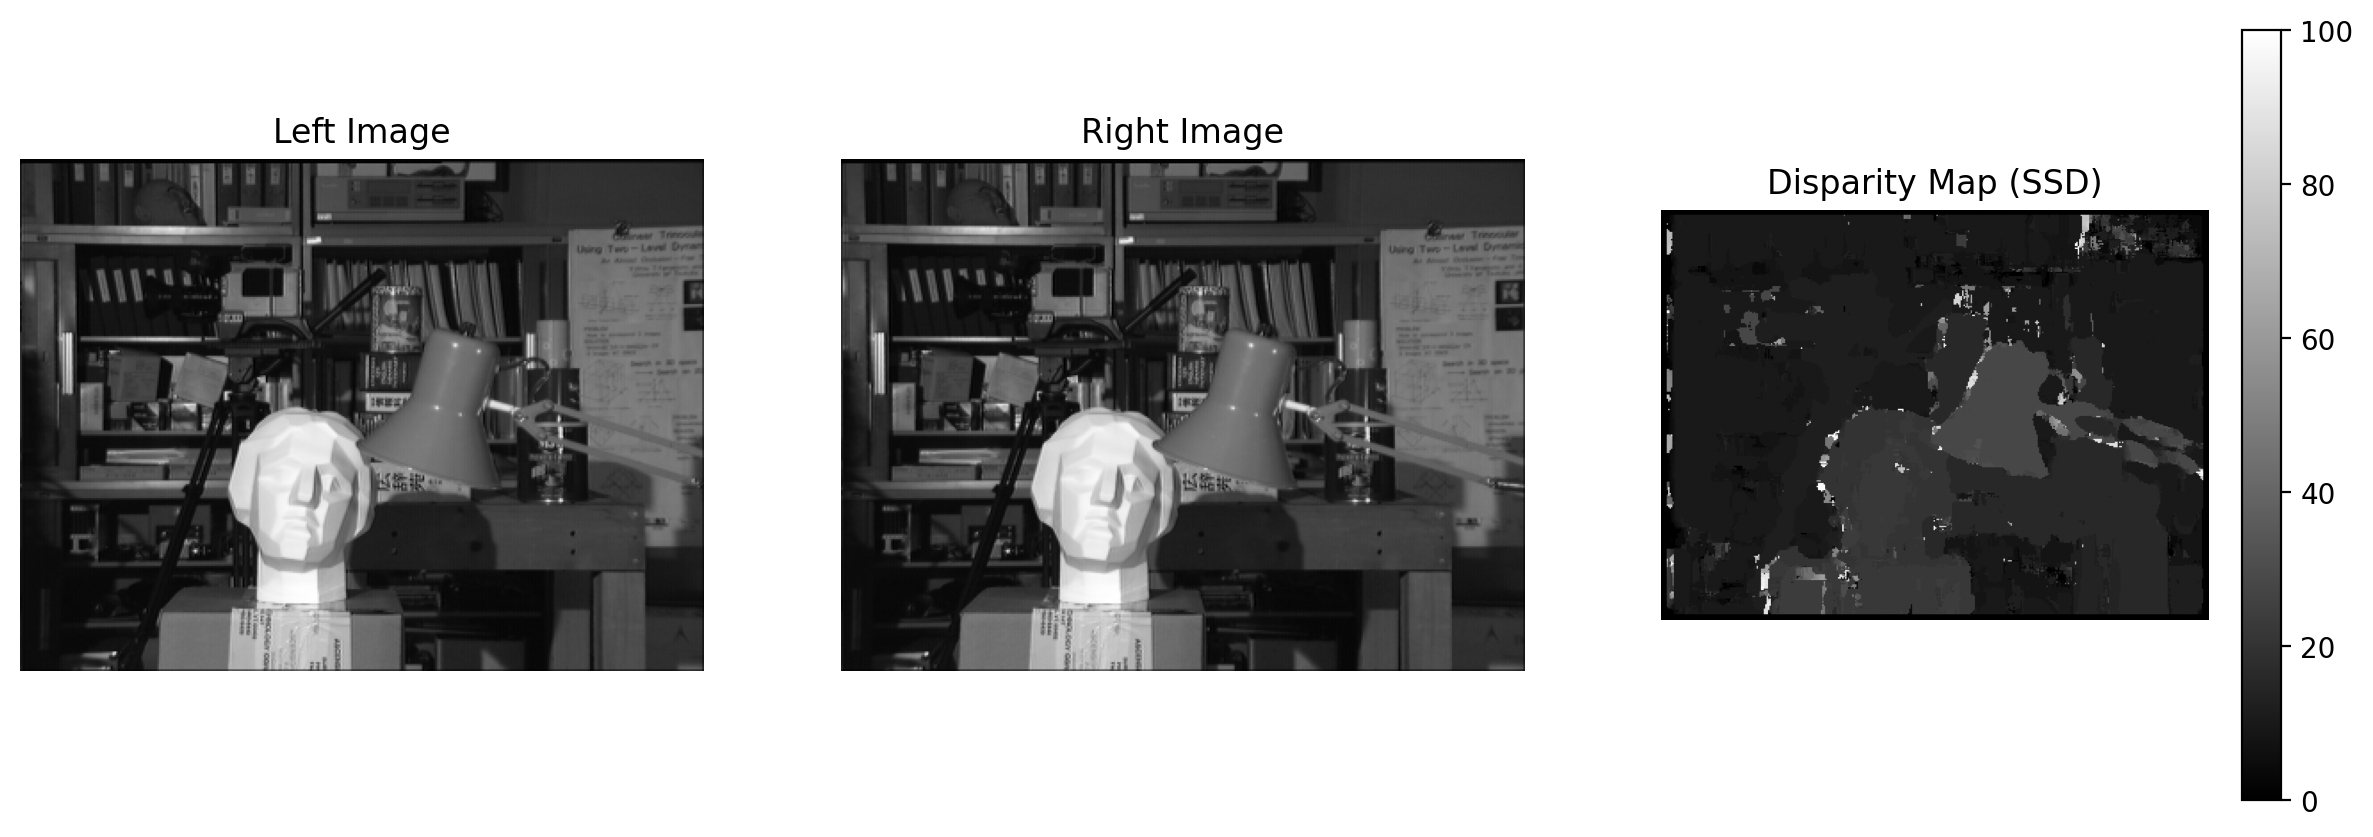

In [28]:
# Load the stereo images
if 'imgL' not in locals() or 'imgR' not in locals():
    imgL = cv.imread('/content/drive/MyDrive/Master I/Computer Vision/lab4/imL.png',0)
    imgR = cv.imread('/content/drive/MyDrive/Master I/Computer Vision/lab4/imR.png',0)

if len(imgL.shape) == 3:
    imgL_gray = cv.cvtColor(imgL, cv.COLOR_BGR2GRAY)
else:
    imgL_gray = imgL

if len(imgR.shape) == 3:
    imgR_gray = cv.cvtColor(imgR, cv.COLOR_BGR2GRAY)
else:
    imgR_gray = imgR

patch_size = 9
search_range = 100

print(f"Computing disparity map with patch size: {patch_size}x{patch_size} and search range: {search_range}")
disparity_ssd = compute_disparity_map_ssd(imgL_gray, imgR_gray, patch_size=patch_size, search_range=search_range)

# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imgL_gray, cmap='gray')
plt.title('Left Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imgR_gray, cmap='gray')
plt.title('Right Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(disparity_ssd, cmap='gray')
plt.title('Disparity Map (SSD)')
plt.colorbar()
plt.axis('off')

plt.show()

### Solution for 4

Based on the description of methods like those in the referenced paper "A Maximum Likelihood Stereo Algorithm" by Ingemar J. Cox et al., we can analyze disparity map estimation.

**Algorithm Type:**
The `cv.StereoBM_create` function, often used in stereo matching, implements a **Block Matching (BM)** algorithm. This is a local method where a block around a pixel in the left image is matched to a similar block in the right image along the same horizontal scanline. The horizontal shift that yields the best match (e.g., minimum SSD) determines the disparity.

**How can it be improved?**
While fast, Block Matching has limitations. Here are ways to enhance disparity map estimation:

1.  **More Robust Cost Functions:** Move beyond simple SSD/SAD to matching costs less sensitive to radiometric changes (e.g., Normalized Cross-Correlation).
2.  **Smoothness Constraints:** Incorporate global optimization methods (dynamic programming, graph cuts) to ensure neighboring pixels have similar disparities, leading to more coherent maps.
3.  **Sub-pixel Accuracy:** Estimate disparities at sub-pixel levels, for instance, by fitting a parabola to the cost function minima.
4.  **Handling Occlusions:** Implement mechanisms to detect and manage occluded regions, which are areas visible in one image but not the other.
5.  **Multi-scale Processing:** Compute disparities at various image scales (e.g., image pyramids) to resolve ambiguities in textureless areas and improve robustness.
6.  **Pre- and Post-filtering:** Apply filters both before (e.g., noise reduction) and after (e.g., median filtering, disparity diffusion) the matching process to enhance map quality.
7.  **Adaptive Support Windows:** Use windows that dynamically adjust their size or shape based on image content, rather than fixed-size blocks.

-----

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. OpenCV SIFT**

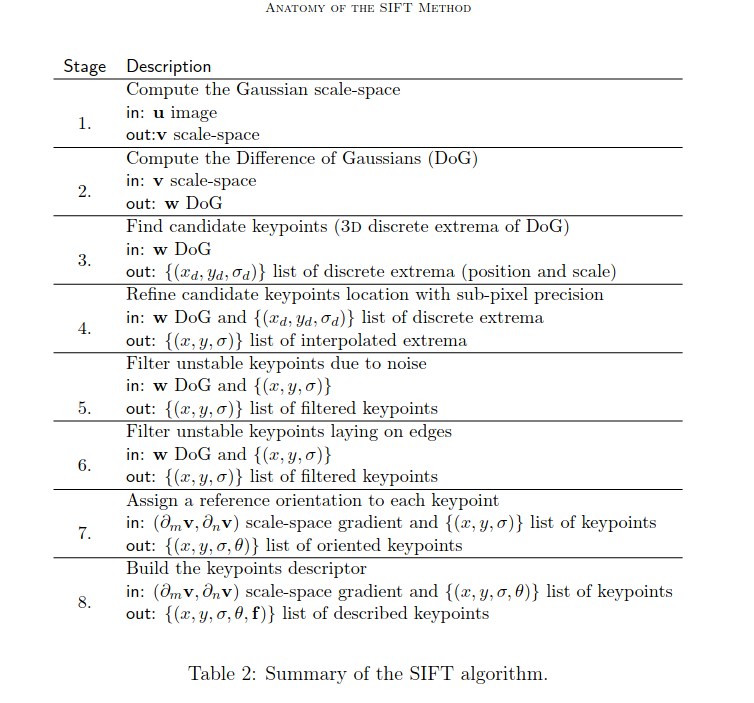

**Documentation**

* [SIFT pipeline](https://www.ipol.im/pub/art/2014/82/article_lr.pdf)
* [SIFT OpenCV](https://docs.opencv.org/master/da/df5/tutorial_py_sift_intro.html)
* [SIFT Video Series](https://www.youtube.com/watch?v=KgsHoJYJ4S8&list=PLlCkKK04bmVlvCs-S-2DnGf08MY2Hdd0n)

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [8, 4]
plt.rcParams['figure.dpi'] = 200

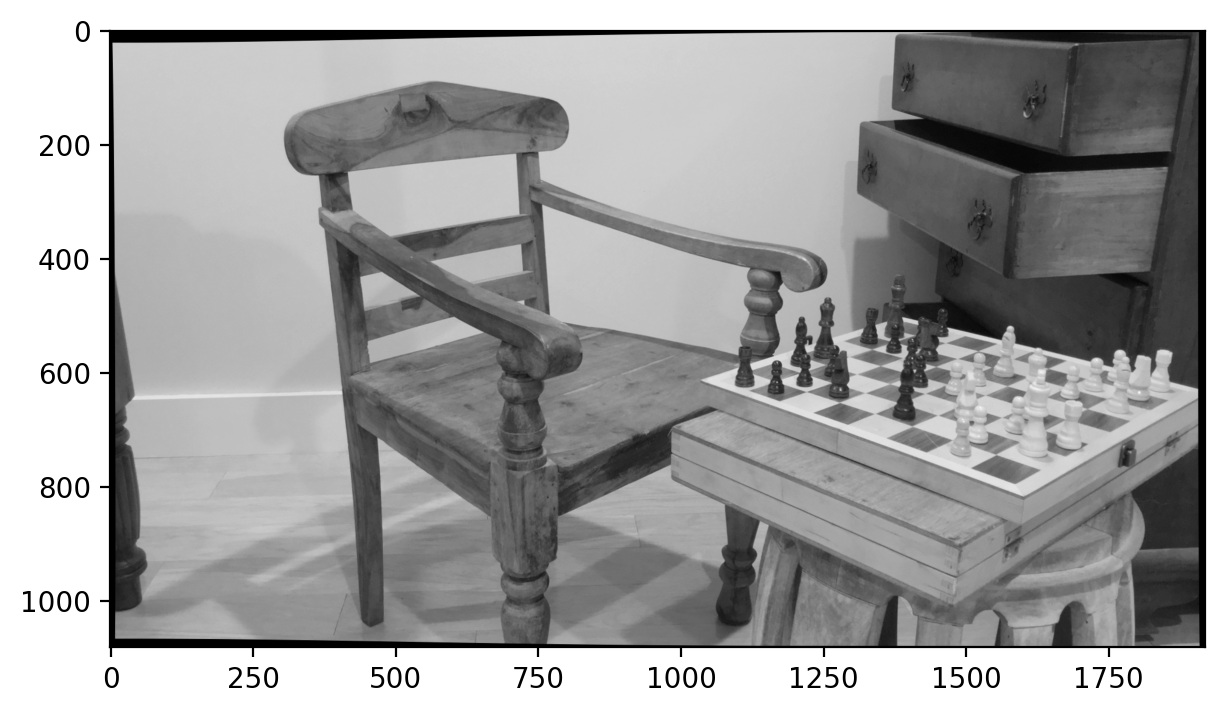

In [5]:
img_left = cv.imread("/content/drive/MyDrive/Master I/Computer Vision/lab4/chess1.png")
img_left_gray = cv.cvtColor(img_left, cv.COLOR_BGR2GRAY)
img_right = cv.imread("/content/drive/MyDrive/Master I/Computer Vision/lab4/chess2.png")
img_right_gray = cv.cvtColor(img_right, cv.COLOR_BGR2GRAY)
plt.imshow(img_left_gray, cmap='gray')


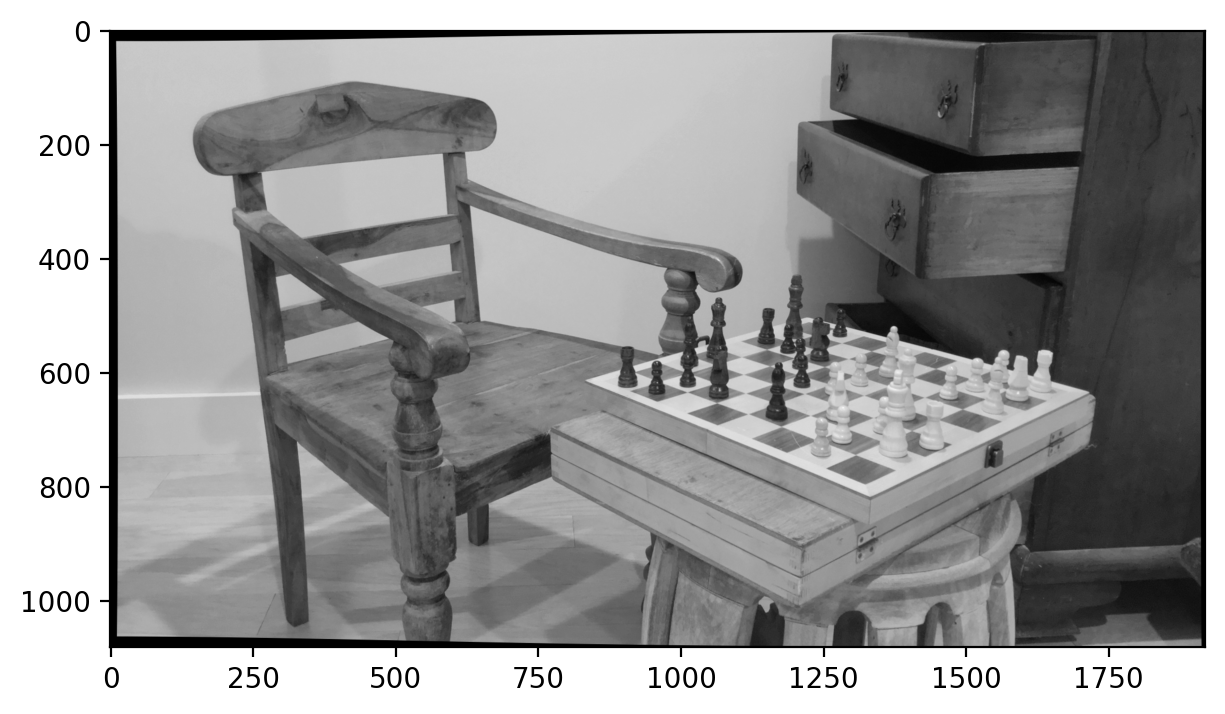

In [ ]:
plt.imshow(img_right_gray, cmap='gray')

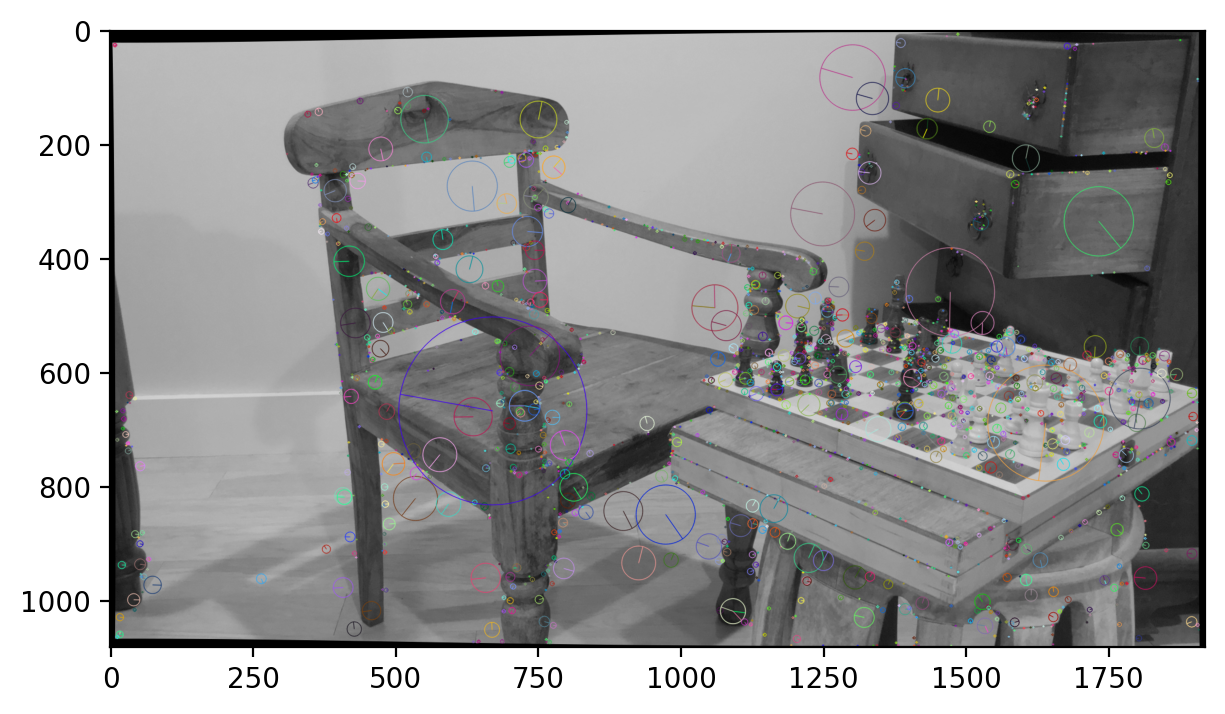

In [ ]:

# next, SIFT will be used to extract features from both images
sift = cv.SIFT_create()
kp_l, desc_l = sift.detectAndCompute(img_left_gray, None)
kp_r, desc_r = sift.detectAndCompute(img_right_gray, None)
desc_img_left = cv.drawKeypoints(img_left_gray, kp_l, img_left, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
desc_img_right = cv.drawKeypoints(img_right_gray, kp_r, img_right, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(desc_img_left)

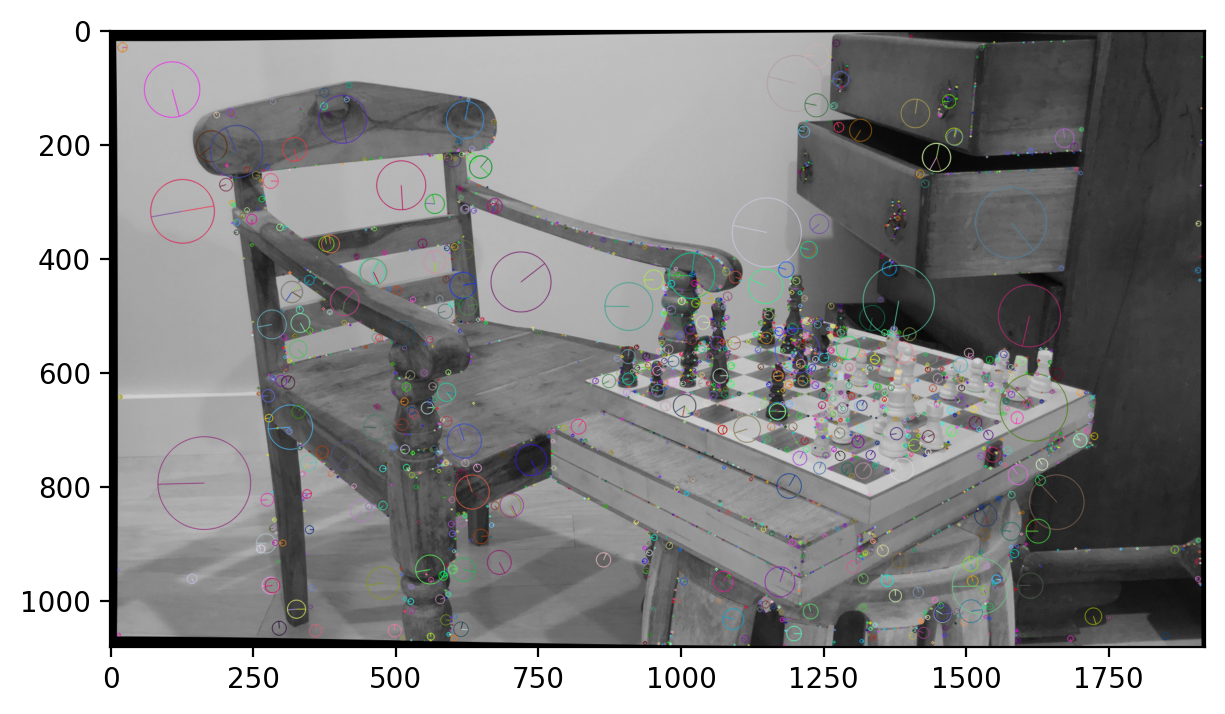

In [ ]:
plt.imshow(desc_img_right)

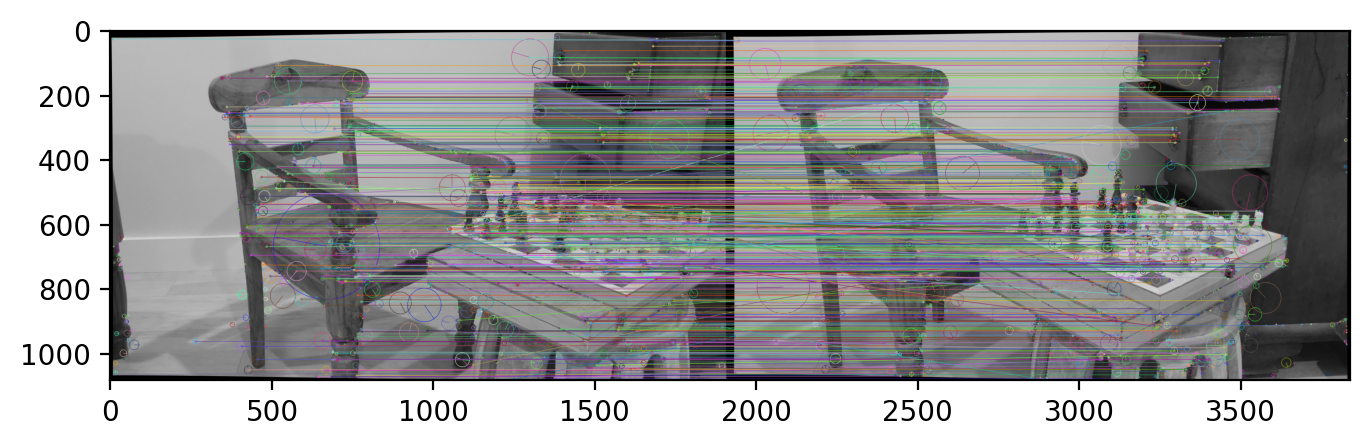

In [ ]:
# next, the sets of feature descriptors are to be matched
bf_matcher = cv.BFMatcher() # BFmatcher is a brute-force matcher based on teh L2 norm
matches = bf_matcher.knnMatch(desc_l, desc_r, k=2) # perform also a ratio test, so we need the first 2 neighbors

kept_matches = []
for m, n in matches:
  if m.distance < 0.75 * n.distance:
    kept_matches.append([m]) # the plotting function need a multi-dimensional data structure, hence the []

# draw matches
img_matches = cv.drawMatchesKnn(img_left, kp_l,  img_right, kp_r, kept_matches,
                                None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_matches)

**2. Otsu's method for tresholding**

Instead of using an arbitrary value for binary thresholding, the otsu's method aims to find a value sunch that the binarization is optimal.

For a binarization to be optimal, both classes are to be well defined and the pixel values corresponding to each class have to be as homogeneous as possible.

Imagine an image representing two different textures. When computing the histogram, it is going to be represented by two peaks for the intensity levels representing the textures (characterized by different colors). A good threshold would be a value in the middle between those two peaks (as in the Gaussian Mixture example from *week 4*).

Otsu's method finds the optimal threshold, using the histogram, such that the missclassification erro is minimal. For this, the *P* values (probabilities for intensity levels) are computed using the normalized histogram. Then, the *q values* are the cumulative sums for the histogram, computed for both classes.

Then, the means (*mu values*) for the classes are computed as weighted sums for intra-cass intensity levels, weighted by the probability of each intensity level, inside it's designed class.

Finally, using the computed means, the variance (*sigma values*) is computed, for each of the classes. In the same fashion, the variance with respect to the class mean is weighted by the intensity level probability, then normalized to the class probability.


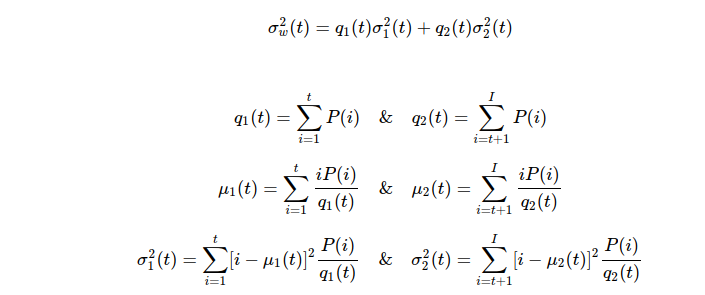


**References**

* [OpenCV description of Otsu's method](https://docs.opencv.org/master/d7/d4d/tutorial_py_thresholding.html)

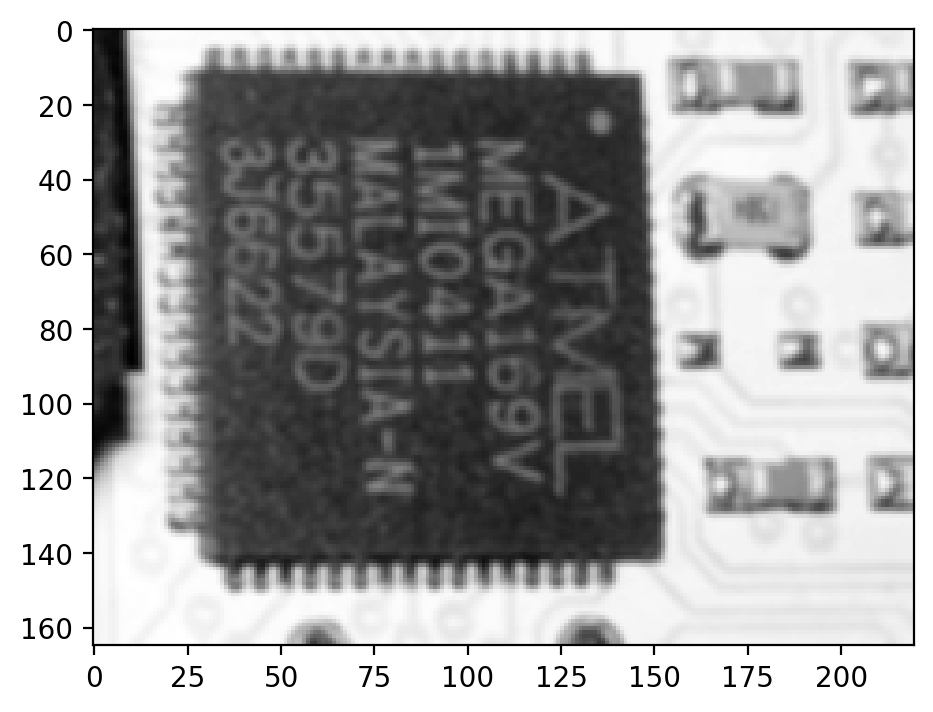

In [ ]:
image_rgb = cv.imread("/content/drive/MyDrive/CAVA_2026/teaching/week5/fingerprint.jpg")
image_rgb = cv.GaussianBlur(image_rgb,(5, 5), 0)
img_gray = cv.cvtColor(image_rgb, cv.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

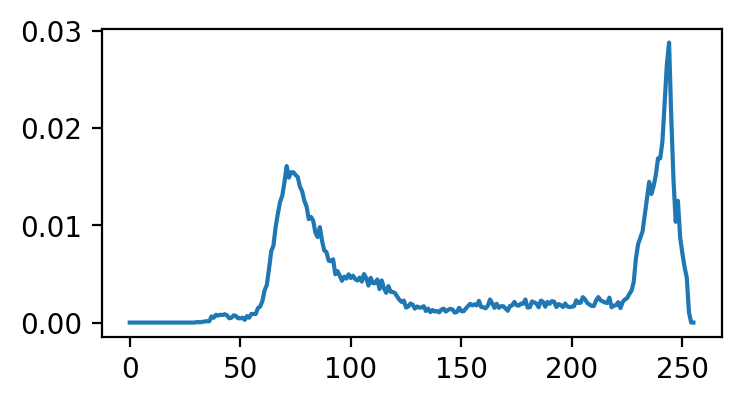

In [ ]:
# now, we will compute the histogram and the cumulative sum over the histogram
histogram = cv.calcHist([img_gray], [0], None, [256], [0, 256])
histogram_normalized = histogram.ravel()/histogram.sum()
# cumulative sum
Q = histogram_normalized.cumsum()

plt.rcParams['figure.figsize'] = [4, 2]
plt.rcParams['figure.dpi'] = 200
plt.plot(np.arange(256), histogram_normalized)

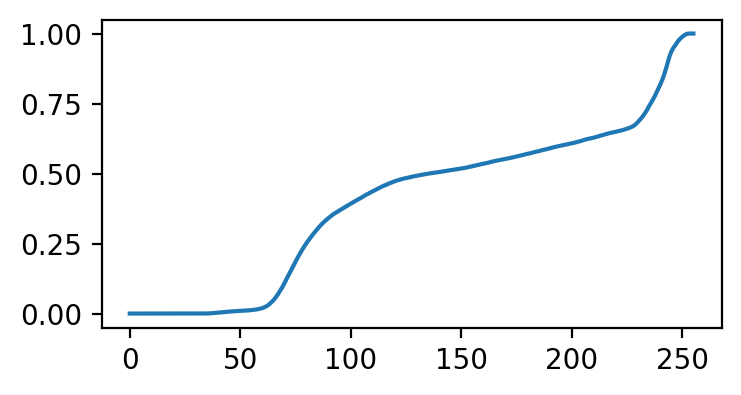

In [ ]:
plt.plot(np.arange(256), Q)

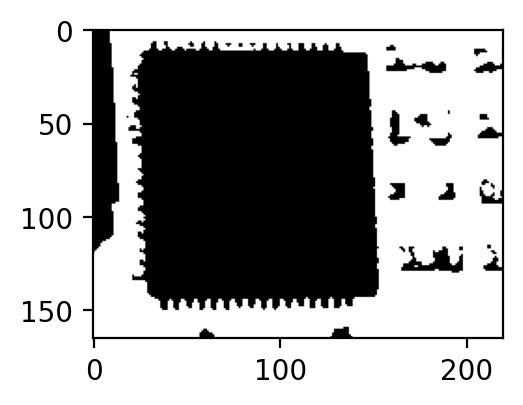

In [ ]:
bins = np.arange(256)
min_variance = np.inf
threshold = -1

# implement the OTSU threshold computation,

for i in range(1, 256):
  p1, p2 = np.split(histogram_normalized, [i]) # assume i is the threshold
  # class probability (Pr(I < i) <= Q), where I is the intensity and
  #i is the fixed possible threshold, and Q is the value of the cumsum histogram at the bin i
  Q1 = Q[i] # Pr(Intensity < i)
  Q2 = Q[255] - Q[i] # Pr(Intensity >= i)

  if Q1 > 1.e-6 and Q2 > 1.e-6: # avoid div by zero
    b1, b2 = np.hsplit(bins, [i]) # intensities corresponding to each class
    # compute class means as the weighted (the probabilities from the normalized histogram)
    # average of the intensities lower than i, then normalize by the blending coeff Q
    m1 = 1/Q1 * np.sum(p1 * b1)
    m2 = 1/Q2 * np.sum(p2 * b2)

    # compute the weighted (same probabilities) average of the variance of each of the segments
    # with respect to their means
    sigma_1 = 1/ Q1 * np.sum(((b1 - m1)**2) * p1)
    sigma_2 = 1/ Q2 * np.sum(((b2 - m2)**2) * p2)

    # compute objective
    total_variance = sigma_1 * Q1 + sigma_2 * Q2

    # choose the threshold i that minimizes the objective
    if total_variance < min_variance:
      min_variance = total_variance
      threshold = i


_, binary_img = cv.threshold(img_gray, threshold, 255, cv.THRESH_BINARY)
plt.imshow(binary_img, cmap='gray')


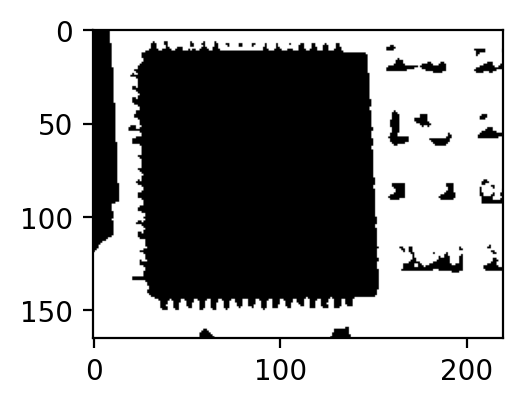

In [ ]:
ret, otsu = cv.threshold(img_gray,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
plt.imshow(otsu, cmap='gray')


**3. GrabCut**

The *Grab Cut* method addresses the challenge of separating object from background in a colored image, given certain constraints. The user is requested to mark a single rectangle around the object, defining the outer part of the rectangle as definite background, and the inner part of it as an unknown combination of the object (foreground) and some background. As explained in the following, these constraints are used as initial solution to the problem, leading to an iterative method which in conclusion aims to assign each pixel in the image its label - Background or Foreground.

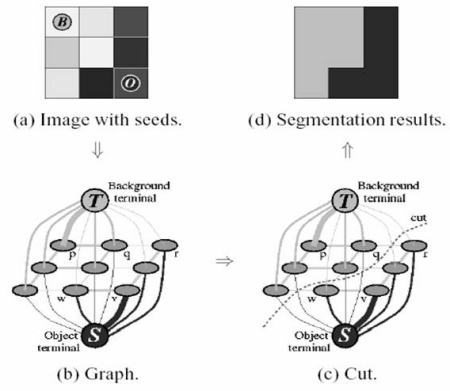

**References**
 * [OpenCV grabcut](https://docs.opencv.org/master/d8/d83/tutorial_py_grabcut.html)

 * [About GrabCut](https://sandipanweb.wordpress.com/2018/02/11/interactive-image-segmentation-with-graph-cut/)

 * [OpenCV implementation paper](https://www.csd.uwo.ca/~yboykov/Papers/pami04.pdf)


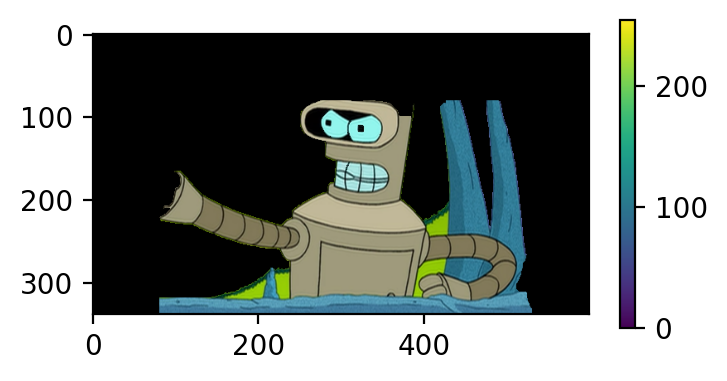

(<matplotlib.image.AxesImage at 0x7bebc9b9eed0>,
 None)

In [ ]:
path = "/content/drive/MyDrive/CAVA_2026/teaching/week5/bender.png"
imgBGR = cv.imread(path)

# allocate space for a binary mask
mask = np.zeros(imgBGR.shape[:2],np.uint8)

# internally used arrays for statistic computation - just allocation
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# a guess of the rectangle enclosing our object in the image
rect = (80, 80, 450, 310)

# 5 is the number of iterations used by the algorithm to refine the reuslts
cv.grabCut(imgBGR, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

# use the mask to do a foreground-background separation
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
img = imgBGR * mask2[:, :, np.newaxis]
plt.imshow(img), plt.colorbar(), plt.show()

**4. Hough Transform**

Hough transform is used in order to detect straight lines throughout the image. The proposed solution of this problem consists of a voting procedure where, for each point in the image corresponding to an edge, a vote is given for every possible line passing through that point.

By identifying the maximum points in the Hough space, the parametric representation of the most probable lines can be determined.

image.png


This parametric represention of the line is not optimal, because both parameters for the slope and elevation can take any value in the real numbers set. Instead, we are shifting to the polar representation, where we have to represent the orientation of the line by the *theta* parameter, and the distance to the origin as the *rho* parameter.

The advantage is that the range of those two parameter is limited (by the image size and by periodicity of the sine function).

image.png


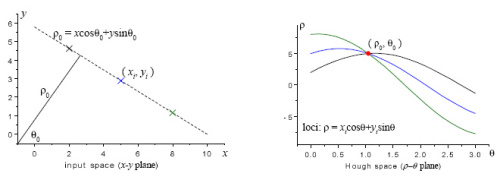

Finally, the solution consists of voting in the *rho, theta* space for any possible line passing through a fixed *x, y* point, that lies on the edge set extracted from the input image. By processing the hough response, extracting local-maximas, we can determine the *rho, theta* parameters describing a line in the image.

Keep in ming that the most probable line is not going to be the most well-defined line in the set of edges. Because of the discretization of the *rho, theta* space, the maximum Hough response will be determined by the bin receiving the most votes by the points lying on the edges. So, a local patch with many points on edges can contribute with more votes than the best well-defined line edge (e. g. *small enough* radius circles with colinear centers).


**References**

* [About Hough Transform](https://dl.acm.org/doi/pdf/10.1145/361237.361242)
* [Canny Edge Detector](https://docs.opencv.org/master/da/d22/tutorial_py_canny.html)
* [Video](https://www.youtube.com/watch?v=XRBc_xkZREg)

In [ ]:
import math


# img should be a h x w x 1 image after canny edge detector
# the function will return the hough response and samples on the most probable line
# as discretization is needed for rho and theta, we will specify the number of bins
# for each parameter
def compute_hough_space(img, rho_bin=200, theta_bin=300):
  h, w = img.shape
  # fix the bounds of the intervals for rho and theta
  theta_max = 1.0 * math.pi
  theta_min = 0.0

  rho_min = 0.0
  rho_max = math.hypot(h, w)

  hough_space = np.zeros((rho_bin, theta_bin))

  for y in range(h):
    for x in range(w):
      # skip points that are not on the edges detected by canny
      if img[y, x] == 0:
        continue
      else:
        # for each point detected, cast a vost in the hough space for each possible line passing through that point
        # this way, the line connecting the points will get a vote from each of the points on the line, being a
        # local maxima in the hough space
        for itheta in range(theta_bin):
          theta = (1.0 * itheta) * (theta_max / theta_bin) # find theta bin
          rho = x * math.cos(theta) + y * math.sin(theta)
          irho = int(rho_bin * rho / rho_max) # find the rho bin
          hough_space[irho, itheta] += 1 # a vote for the given point

  # find the most probable line
  r, t = np.unravel_index(np.argmax(hough_space, axis=None), hough_space.shape)
  r_max = r / rho_bin * rho_max
  t_max = t / theta_bin * theta_max

  # make sure you test for sin(theta) = 0 when extending the demo
  x = np.arange(w)
  y = 1/math.sin(t_max) * (r_max - x * math.cos(t_max))

  # normalize the hough response to a grayscale image, for vizualization
  hough_space = np.ceil(255 * (hough_space - hough_space.min())/(hough_space.max() - hough_space.min()))
  return hough_space.astype(np.uint8), x, y


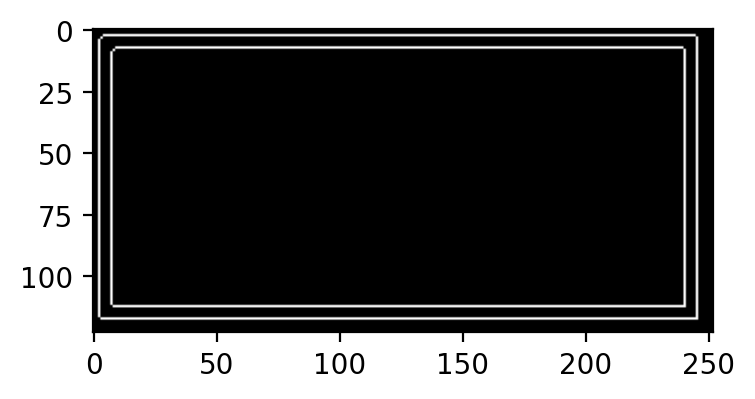

In [ ]:
image_rgb = cv.imread("/content/drive/MyDrive/CAVA_2026/teaching/week5/rectangle.png")
img_gray = cv.cvtColor(image_rgb, cv.COLOR_BGR2GRAY)

# after converting the image to grayscale, apply a canny edge detector
edges = cv.Canny(img_gray,100,200)
plt.imshow(edges, cmap ='gray')

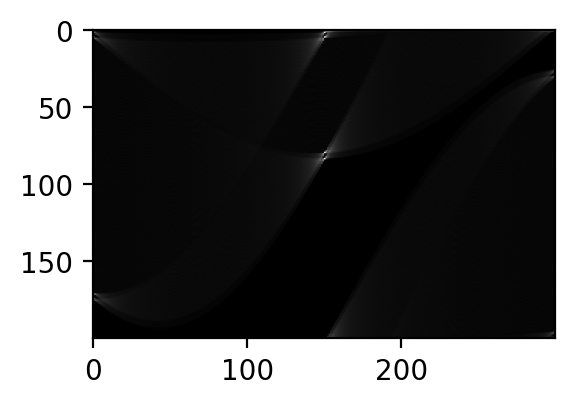

In [ ]:
response, x, y = compute_hough_space(edges)
plt.imshow(response, cmap='gray')

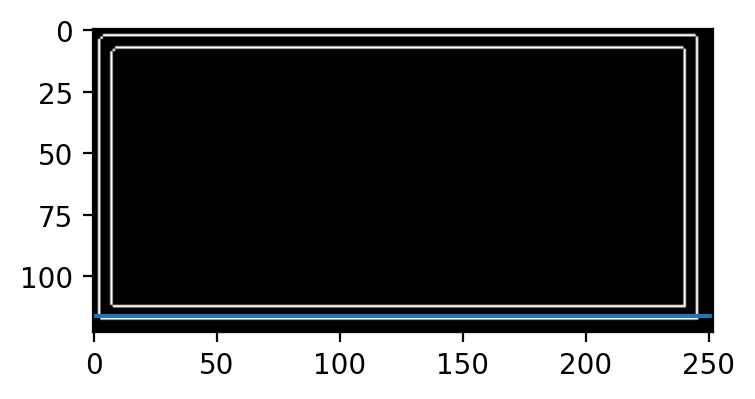

In [ ]:
plt.imshow(edges, cmap='gray')
plt.plot(x, y)

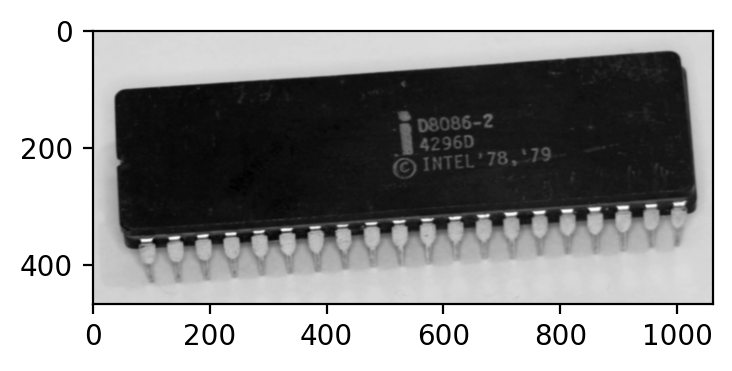

In [ ]:
image_rgb = cv.imread("/content/drive/MyDrive/CAVA_2026/teaching/week5/8086.jpg")
image_rgb = cv.GaussianBlur(image_rgb,(5, 5), 0)
img_gray = cv.cvtColor(image_rgb, cv.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

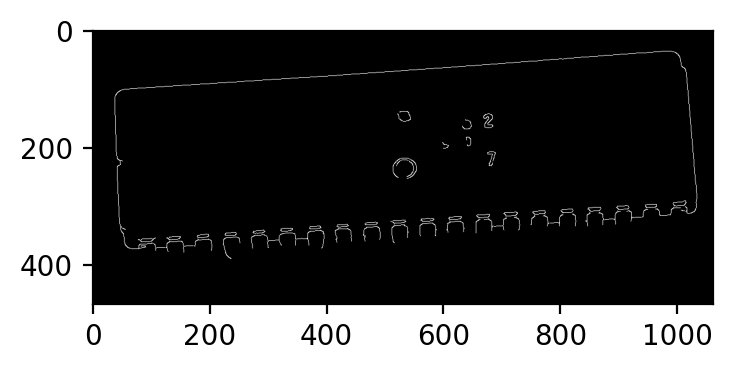

In [ ]:
edges = cv.Canny(img_gray, 100, 200)
plt.imshow(edges, cmap='gray')

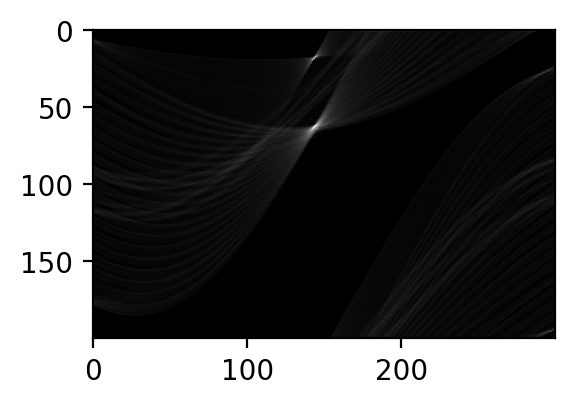

In [ ]:
hough_response, x, y = compute_hough_space(edges)
plt.imshow(hough_response, cmap='gray')

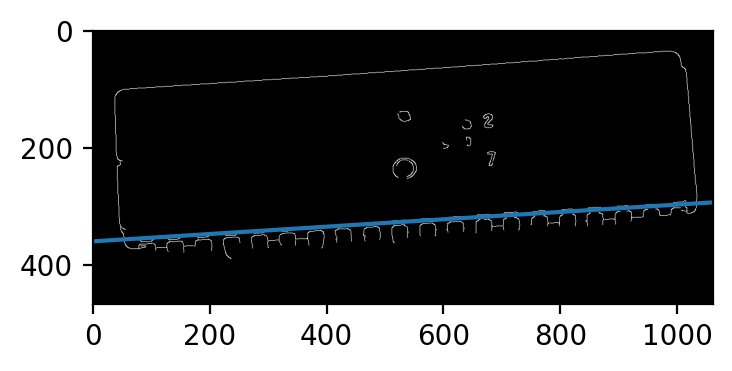

In [ ]:
plt.imshow(edges, cmap='gray')
plt.plot(x, y)

**5. Stereo matching**

The figure presented in this section represents the *stereo vision* setup. Two different cameras are used to capture the same object. The center posision of both camera is, evidently known. The line between the camera centers is called *baseline*, and it can be used to determine a 3D model of the observed object.
Each optical center projects in the other image as a point called *the epipole*. The epipole is characteristic to each of the images.

The *epipolar plane* is the plane spanned by a set of three points, the camera centers and the position of the observed point. The intersection between the epipolar plane and both image planes determines the *epipolar lines* in both images.  

Both cameras are characterized by their respective image plane. The lines between the observed point and each camera center are called *lines of sight*.
As you can see, there exists a transformation between the left image representation and the right image representation. This transformation is called the *fundamental matrix*.

 If the line *P1-P3* is going to be matched, it will appear like a line in the *right image* and a point in the *left image*. So, the transformation is rank deficient.

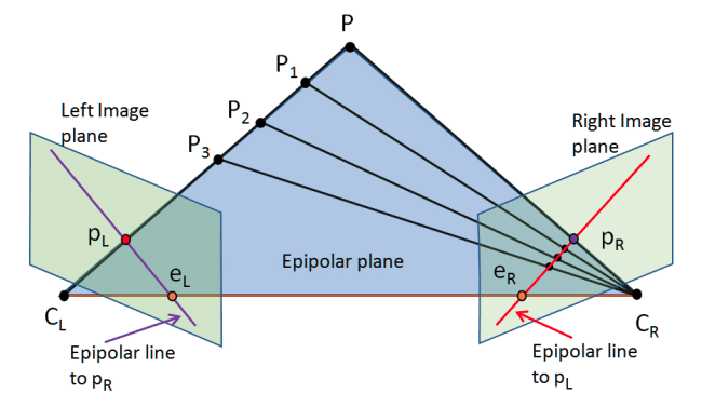


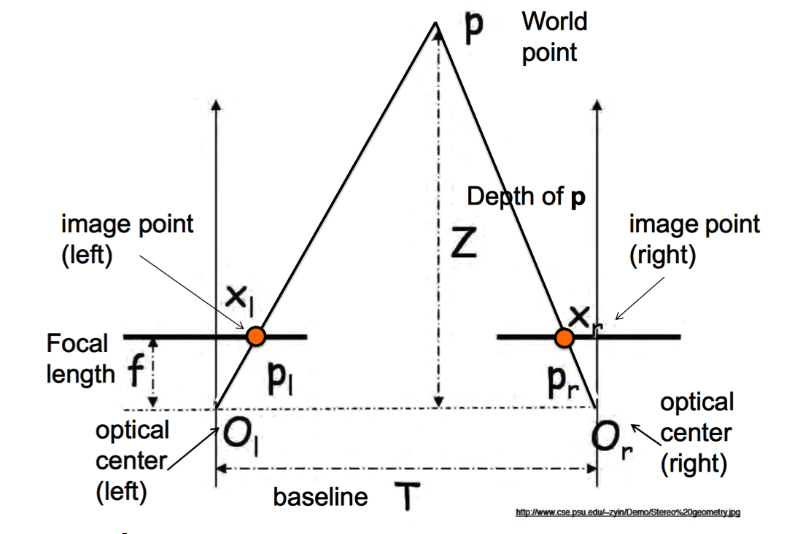

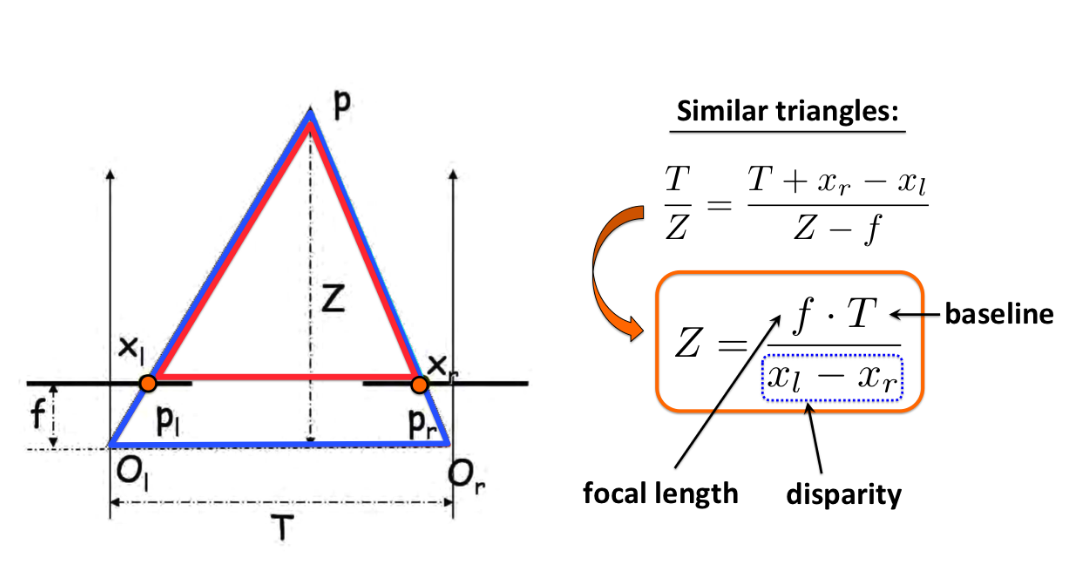


**References**

* [Stereo matching](http://www.cs.toronto.edu/~fidler/slides/2017/CSC420/lecture12_hres.pdf)

* Ingemar J. Cox, Sunita L. Hingorani, Satish B. Rao, Bruce M. Maggs,
A Maximum Likelihood Stereo Algorithm,
Computer Vision and Image Understanding,
Volume 63, Issue 3,
1996,
Pages 542-567,
ISSN 1077-3142,


In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

imgL = cv.imread('/content/drive/MyDrive/CAVA_2026/teaching/week5/imL.png',0)
imgR = cv.imread('/content/drive/MyDrive/CAVA_2026/teaching/week5/imR.png',0)
stereo = cv.StereoBM_create(numDisparities=16, blockSize=15)


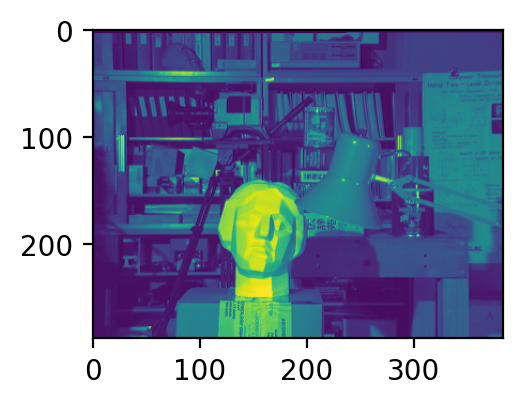

In [ ]:
plt.imshow(imgL)

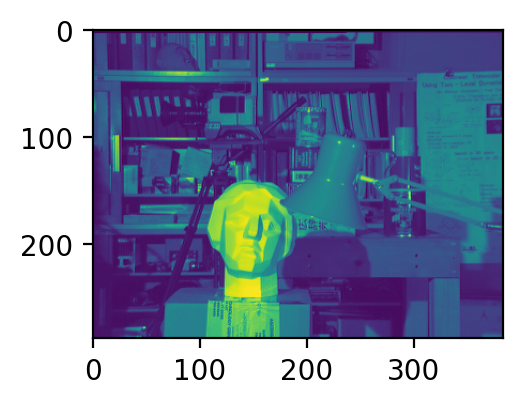

In [ ]:
plt.imshow(imgR)

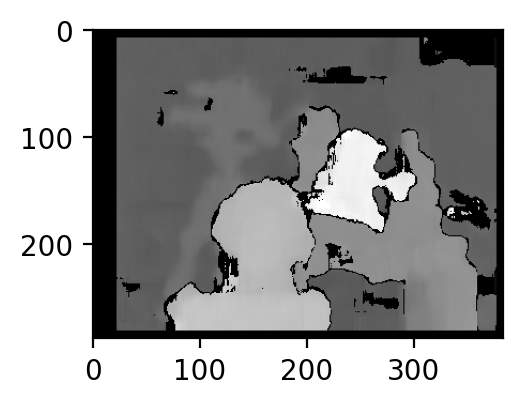

In [ ]:
# observe the intensity level in the disparity map and remember the fact
# the disparity is inversely proportional to the real world depth from the camera
# center to the object represented in the image

disparity = stereo.compute(imgL,imgR)
plt.imshow(disparity,'gray')
plt.show()